<a href="https://colab.research.google.com/github/AidaAm005/Stochastic-Processes-Final-Project/blob/main/SPFinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Processes Final Project

**Instructor: Dr. Peyvandi**

Students' Names: Aida Ameri - Sajjad Mohammadbeigi

Students' IDs: 403100202 - 403170066



# Applications of Gaussian Processes
First you will be introduced to Gaussian Processes. You will bridge continuous-time stochastic processes and discrete computational inference. You will build a Gaussian Process (GP) regression framework from scratch, sample hyperparameter distributions using Markov Chain Monte Carlo (MCMC), and implement a score-driven diffusion process using Langevin dynamics.

**Project Overview & Objectives**

1. Construct Gaussian Process (GP) prior spaces from foundational mathematical kernels.

2. Derive and implement the analytical updates for Gaussian Process Regression under noisy observations.

3. Transition to sampling-based inference by building a Metropolis-Hastings MCMC sampler to optimize function space hyperparameters over a log-marginal likelihood surface.

4. Simulate a continuous-time Itô diffusion via the Euler-Maruyama discretization scheme using the Unadjusted Langevin Algorithm (ULA).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Gaussian Process

Recall that a random vector $X \sim \mathcal{N}(\mu, \Sigma)$ has a multivariate normal distribution defined by its mean vector $\mu$ and covariance matrix $\Sigma$. Its probability density function is:$$f(x) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x-\mu)^\top \Sigma^{-1} (x-\mu)\right)$$

A stochastic process $\{X(t) \mid t \in T\}$ is a Gaussian Process (GP) if and only if every finite dimensional projection (i.e., every finite subset $\{X(t_1), \dots, X(t_n)\}$) is jointly Gaussian. A GP is completely specified by its mean function $m(t) = \mathbb{E}[X(t)]$ and its covariance function (kernel) $k(s, t) = \mathbb{E}[(X(s) - m(s))(X(t) - m(t))]$.

The choice of the kernel function encodes structural assumptions about the underlying stochastic process:
- **Radial Basis Function (RBF) Kernel:** Defines a stationary process where covariance depends only on the distance between inputs. It is infinitely mean-square differentiable, forcing the generated sample paths to be incredibly smooth.
$$k_{RBF}(x, x') = \sigma^2 \exp\left(-\frac{\|x - x'\|^2}{2\ell^2}\right)$$

- **Brownian Motion (Wiener Process) Kernel:** Defines a non-stationary process indexable for $t \geq 0$ with independent increments where $W(0) = 0$. Its sample paths are continuous everywhere but differentiable nowhere.
$$k_{BM}(s, t) = \min(s, t)$$

Task 1: Implement both the RBF and Brownian motion kernels, construct their respective covariance matrices, and draw random sample paths from each GP prior.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def rbf_kernel(x1, x2, sigma=1.0, length_scale=1.0):
    """
    Computes the RBF (squared-exponential) kernel matrix between two vectors.
    """
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2).T

    # TODO: Calculate the pairwise squared Euclidean distance matrix between x1 and x2
    sqdist = (x1 - x2.T) ** 2
    # مکانیزم NumPy Broadcasting
    # این روش بدون نیاز به حلقه‌های کند فور، تفاضل دوتایی تمام نقاط را در یک ماتریس دوبعدی حساب می‌کند.

    # TODO: Return the scaled exponential covariance matrix
    return (sigma ** 2) * np.exp(-sqdist / (2 * (length_scale ** 2)))
    # فرمول ریاضی کرنل آر‌بی‌اف برای محاسبه ماتریس کوواریانس و سنجش شباهت نقاط
    # پارامتر ال اسکیل میزان همواری افقی و سیگما مقیاس نوسانات عمودی را تنظیم می‌کنند.

def brownian_kernel(x1, x2):
    """
    Computes the covariance matrix for a standard Brownian motion k(s, t) = min(s, t).
    Assumes inputs are non-negative.
    """
    x1 = np.atleast_2d(x1).T
    x2 = np.atleast_2d(x2).T

    # TODO: Calculate min(s, t) for all pairs using numpy vectorization
    return np.minimum(x1, x2.T)
    # محاسبه مینیمم زمان‌ها برای *زوج‌نقاط* در فرآیند حرکت براونین به صورت برداری. با np.minimum به جای np.min
    # طبق تعریف ریاضی، تابع کوواریانس حرکت براونین برابر با مینیمم زمان‌ها است.

# --- Domain Setups ---
x_rbf = np.linspace(-5, 5, 200)
x_brownian = np.linspace(0, 10, 500) # Standard Brownian motion starts at t=0

# --- Covariance Matrix Generation ---
# TODO: Compute the RBF and Brownian kernel matrices over their respective domains
K_rbf = rbf_kernel(x_rbf, x_rbf)
K_brownian = brownian_kernel(x_brownian, x_brownian)
# تشکیل ماتریس‌های کوواریانس کامل برای هر دو کرنل روی تمام نقاط.
# این ماتریس‌ها ساختار چگالی احتمال مشترک فرآیند گاوسی پیشین را مشخص می‌کنند.

# Add a tiny noise term to the diagonals for numerical stability (jitter)
K_rbf += 1e-8 * np.eye(len(x_rbf))
K_brownian += 1e-8 * np.eye(len(x_brownian))

# --- Prior Sampling ---
# TODO: Draw 5 sample paths from each GP prior using `np.random.multivariate_normal`
samples_gaussian = np.random.multivariate_normal(np.zeros(len(x_rbf)), K_rbf, size=5)
samples_brownian = np.random.multivariate_normal(np.zeros(len(x_brownian)), K_brownian, size=5)
# نمونه‌برداری از توزیع نرمال چندمتغیره با میانگین صفر و ماتریس‌های کوواریانس یافته‌شده.
# هر سطر از خروجی، یک مسیر فرکانسی گسسته‌ شده از فرآیند پیشین را شبیه‌سازی می‌کند.

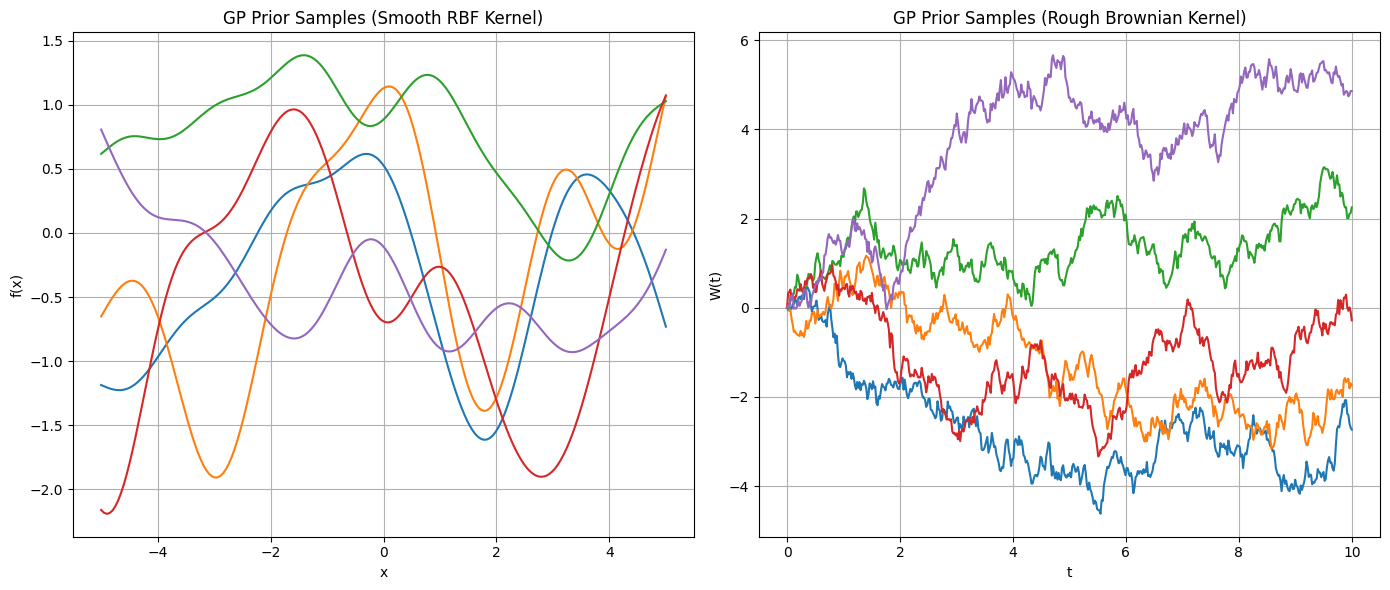

In [2]:
# --- Visualizing the Sample Paths ---
plt.figure(figsize=(14, 6))

# Plot RBF Samples
plt.subplot(1, 2, 1)
for s in samples_gaussian:
    plt.plot(x_rbf, s)
plt.title("GP Prior Samples (Smooth RBF Kernel)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# Plot Brownian Motion Samples
plt.subplot(1, 2, 2)
for s in samples_brownian:
    plt.plot(x_brownian, s)
plt.title("GP Prior Samples (Rough Brownian Kernel)")
plt.xlabel("t")
plt.ylabel("W(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: justify; line-height: 1.8; font-family: tahoma, arial;">

## تحلیل تسک ۱ (GP Priors)
پس از پیاده‌سازی کرنل‌ها و نمونه‌برداری از Prior Spaces، نمودارها تفاوت ساختاری بین دو فرآیند تصادفی را نشان می‌دهند:

### ۱. فرآیند پیشین با کرنل RBF (نمودار سمت چپ)
* **پیوستگی و همواری بی‌نهایت:** هر ۵ مسیر نمونه‌برداری‌شده رفتار نرم، هموار و بدون شکستگی دارند. از نظر ریاضی، کرنل RBF به دلیل فرم نمایی، در تمام مرتبه‌ها Mean-Square Differentiable است. این باعث می‌شود مسیرهای تولید شده برای مدل‌سازی پدیده‌های طبیعی نرم (مثل تغییرات دما) مناسب باشند.
* **Stationarity:** میزان نوسانات عمودی توابع در طول محور $x$ در محدوده مشخصی باقی می‌ماند. این به این دلیل است که کوواریانس بین دو نقطه در کرنل RBF، صرفا به فاصله مطلق آن‌ها از یکدیگر ($||x - x'||$) وابسته است، نه به موقعیت آن‌ها در فضا.

### ۲. فرآیند پیشین حرکت براونین (نمودار سمت راست)
* **پیوسته اما مشتق‌ناپذیر:** مسیرهای حاصل کاملا دندانه‌ای، خشن و Rough هستند. این نمودار نشان‌دهنده یک فرآیند تصادفی است که در همه جا پیوسته است اما در هیچ نقطه‌ای مشتق‌پذیر نیست. هر گام جدید در این فرآیند، یک Independent Increment به گام قبلی است.
* **Non-Stationarity و نقطه شروع:** بر خلاف RBF، تمام مسیرهای براونین از نقطه $W(0) = 0$ آغاز شده‌اند. با حرکت به سمت راست و افزایش زمان، واگرایی و پراکندگی مسیرها از یکدیگر افزایش می‌یابد. دلیل آن است که واریانس حرکت با زمان رابطه مستقیم دارد ($\text{Var}(W(t)) = t$)؛ بنابراین هرچه زمان می‌گذرد، عدم قطعیت مدل بیشتر می‌شود.

### نتیجه‌گیری
خروجی این تسک نشان می‌دهد که انتخاب کرنل چقدر در پیش‌فرض‌های ما درباره یک سیستم تصادفی موثر است؛ کرنل اول فرضیه تغییرات نرم و هماهنگ را ایجاد می‌کند و کرنل دوم فرضیه تغییرات آنی و مستقل را ایجاد می‌کند.

</div>

## GP Regression

Assume we observe a training dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$ governed by an underlying latent target function $f(x)$ corrupted by independent and identically distributed (i.i.d.) Gaussian measurement noise $\epsilon_i$:
$$y_i = f(x_i) + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma_y^2)$$

By placing a non-parametric prior distribution over the target function space, $f \sim \mathcal{GP}(0, k)$, the joint distribution of our observed training outputs $y \in \mathbb{R}^n$ and the unobserved latent target evaluations $f_* \in \mathbb{R}^{m}$ at test locations $X_*$ can be structurally arranged as a partitioned multivariate normal distribution:

$$\begin{bmatrix} y \\ f_* \end{bmatrix} \sim \mathcal{N} \left( 0, \begin{bmatrix} K(X,X) + \sigma_y^2 I_n & K(X,X_*) \\ K(X_*,X) & K(X_*,X_*) \end{bmatrix} \right)$$

Applying the Linear Gaussian Conditioning Theorem, the conditional distribution $f_* \mid X, y, X_*$ preserves its Gaussian identity, yielding the posterior predictive distribution $\mathcal{N}(\mu_*, \Sigma_*)$, defined by:
$$\mu_* = K(X_*, X) \left[ K(X,X) + \sigma_y^2 I_n \right]^{-1} y$$$$\Sigma_* = K(X_*, X_*) - K(X_*, X) \left[ K(X,X) + \sigma_y^2 I_n \right]^{-1} K(X, X_*)$$

Task 2: Compute the predictive conditional operators to translate a prior functional space into a data-constrained posterior representation.

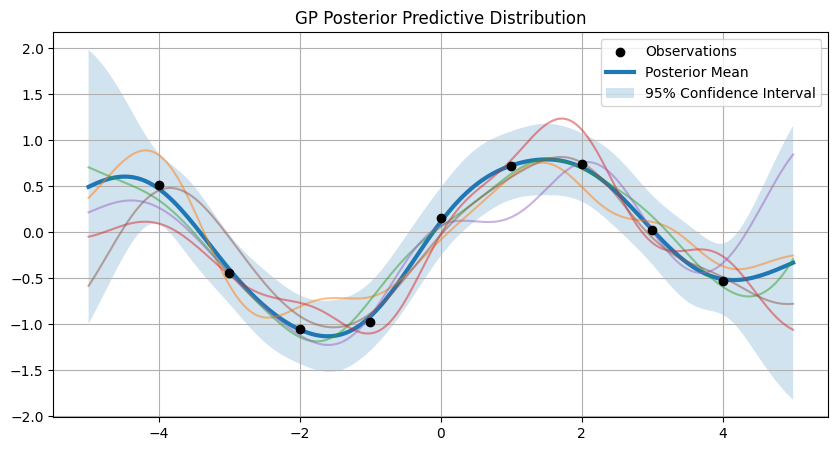

In [5]:
# --- Data Generation ---
def true_function(x):
    return np.sin(x)

x = np.linspace(-5, 5, 200)
x_train = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4])
noise_var = 0.2**2
y_train = true_function(x_train) + np.sqrt(noise_var)*np.random.randn(len(x_train))

# --- Posterior Computation ---
# TODO: Compute the required covariance matrices: K_xx, K_xs, K_ss
# Ensure you add the noise variance to the diagonal of K_xx!
K_xx = rbf_kernel(x_train, x_train) + noise_var * np.eye(len(x_train))
K_xs = rbf_kernel(x_train, x)
K_ss = rbf_kernel(x, x)
# تشکیل بخش‌های مختلف ماتریس کوواریانس مشترک طبق ساختار بالا
# اضافه کردن واریانس نویز به قطر ماتریس آموزش به دلیل وجود خطای اندازه‌گیری در داده‌ها است.

# TODO: Compute the inverse of K_xx
# Hint: For better numerical stability in production code, we typically use Cholesky
# decomposition, but np.linalg.inv is acceptable for this assignment.
K_inv = np.linalg.inv(K_xx)
# محاسبه وارون ماتریس کوواریانس آموزش برای استفاده در فرمول‌های شرطی‌سازی.

# TODO: Compute the posterior mean and covariance
mu_post = K_xs.T @ K_inv @ y_train
cov_post = K_ss - K_xs.T @ K_inv @ K_xs
# فرمول‌های اصلی قضیه شرطی‌سازی گاوسی خطی برای به دست آوردن مشخصات توزیع پسین.
# میانگین پسین پیش‌بینی نهایی مدل و کوواریانس پسین میزان خطای حدس ما را مشخص می‌کنند.

# Sample from the posterior
posterior_samples = np.random.multivariate_normal(
    mu_post,
    cov_post + 1e-8*np.eye(len(x)),
    size=5
)

# Plotting the Posterior
plt.figure(figsize=(10,5))
plt.scatter(x_train, y_train, color="black", zorder=5, label="Observations")
plt.plot(x, mu_post, linewidth=3, label="Posterior Mean")

std = np.sqrt(np.diag(cov_post))
plt.fill_between(x, mu_post - 2*std, mu_post + 2*std, alpha=0.2, label="95% Confidence Interval")

for s in posterior_samples:
    plt.plot(x, s, alpha=0.5)

plt.title("GP Posterior Predictive Distribution")
plt.legend()
plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: justify; line-height: 1.8; font-family: tahoma, arial;">

## تحلیل تسک ۲ (GP Regression)

 با بررسی دقیق پلات فرآیند گاوسی پسین، سه رفتار مهم قابل تحلیل است:

### ۱. اثر The Pinch Effect
 هر جا که یک نقطه داده‌ی واقعی (نقاط سیاه رنگ) وجود دارد، پهنای نوار آبی‌ که  بازه اطمینان ۹۵ درصدی ($\pm 1.96 \sigma$) است، منقبض و باریک می‌شود.
* **علت:** در فرمول کوواریانس پسین، جمله دوم یعنی $K_{xs}^T K_{xx}^{-1} K_{xs}$ میزان اطلاعاتی است که از داده‌های آموزش کسب شده است. این ترم از کوواریانس پیشین ($K_{ss}$) کسر می‌شود و واریانس را در نزدیکی نقاط دیده‌شده کاهش می‌دهد.
*  نوار آبی در محل نقاط سیاه کاملا به صفر نچسبیده است. دلیل آن هایپرپارامتر `noise_var` ($\sigma_y^2$) است. مدل فرض می‌کند داده‌ها با نویز گاوسی آلوده شده‌اند، بنابراین حتی روی خود نقاط آموزش هم حدی از عدم قطعیت را حفظ می‌کند.

### ۲. بازگشت به توزیع پیشین (Prior Reversion)
با فاصله گرفتن از نقاطِ داده (به‌ویژه در لبه‌های نمودار یعنی $x > 4$ و $x < -4$)، نوار بازه اطمینان مجددا باز و پهن می‌شود.
* **علت:** وقتی از نقاط آموزش دور می‌شویم، میزان شباهت و همبستگی نقاط تست با نقاط آموزش ($K_{xs}$) به صفر میل می‌کند. با صفر شدن این جمله، کوواریانس پسین دوباره برابر با همان کوواریانس پیشین ($K_{ss}$) می‌شود. این نشان می‌دهد مدل در نواحی بدون داده، هیچ ایده‌ای ندارد و عدم قطعیت خود را به حداکثر می‌رساند.

### ۳. رفتار مسیرهای نمونه‌برداری پسین (Posterior Sample Paths)
خطوط رنگی، ۵ مسیر تصادفی هستند که از این توزیع پسین نمونه‌برداری شده‌اند. برخلاف تسک ۱ که مسیرها در کل فضا پخش بودند، اینجا تمامی این ۵ خط مجبور شده‌اند از مرزهای ایجادشده توسط داده عبور کنند و به طور هماهنگ، نوسانات خط میانگین پسین (خط آبی ضخیم) را شبیه‌سازی نمایند. این درستی نمونه‌برداری از توزیع نرمال چندمتغیره شرطی را تایید می‌کند.

### نتیجه‌گیری
فرآیند گاوسی فراتر از یک رگرسیون ساده است؛ این مدل نه تنها یک Posterior Mean به ما می‌دهد، بلکه معیاری از سطح ندانسته‌های خود (Posterior Covariance) نیز هست.

</div>

## MCMC: Bayesian Inference Over Hyperparameters

In practical settings, fixing hyperparameters like the kernel length scale $\ell$ can lead to severe underfitting or overfitting. A fully Bayesian approach treats these parameters as random variables rather than static design choices.
We define the hyperparameter posterior distribution over the length scale $\ell$ given our data via Bayes' Theorem:
$$\pi(\ell) = p(\ell \mid X, y) = \frac{p(y \mid X, \ell) p(\ell)}{p(y \mid X)} \propto p(y \mid X, \ell) p(\ell)$$
, Where:
- $p(\ell)$ is the prior distribution over the hyperparameter, encoding our engineering assumptions (e.g., ensuring $\ell > 0$).
- $p(y \mid X, \ell)$ is the marginal likelihood (the evidence), which integrates out the latent function values $f$.

For Gaussian Processes, the log marginal likelihood is analytically tractable and can be expressed as:
$$\log p(y \mid X, \ell) = \underbrace{-\frac{1}{2} y^\top K_{\ell}^{-1} y}_{\text{Data Fit Term}} - \underbrace{\frac{1}{2} \log |K_{\ell}|}_{\text{Complexity Penalty}} - \underbrace{\frac{n}{2} \log(2\pi)}_{\text{Normalization Constant}}$$

The Occam's Razor Penalty: Notice the tension between the first two terms. As the length scale $\ell$ shrinks, the kernel becomes highly flexible, optimizing the Data Fit Term but causing the determinant $|K_{\ell}|$ to explode, which heavily penalizes the model via the Complexity Penalty.

**The Metropolis-Hastings Algorithm**:

 Because the normalizing constant $p(y \mid X) = \int p(y \mid X, \ell)p(\ell)d\ell$ is analytically intractable, we cannot sample from $\pi(\ell)$ directly. Instead, we construct an ergodic Markov chain $\{\ell_0, \ell_1, \dots, \ell_N\}$ whose stationary distribution is exactly $\pi(\ell)$.

 Given a state $\ell^{(t)}$, we sample a candidate state $\ell^*$ from a symmetric proposal distribution $q(\ell^* \mid \ell^{(t)}) \sim \mathcal{N}(\ell^{(t)}, \tau^2)$. The candidate is accepted with probability:$$\alpha(\ell^{(t)}, \ell^*) = \min\left(1, \frac{\pi(\ell^*)}{\pi(\ell^{(t)})}\right)$$To ensure numerical stability and prevent arithmetic underflow, we evaluate this condition entirely in log-space:$$\log \alpha = \log \pi(\ell^*) - \log \pi(\ell^{(t)})$$If a random draw from $\log U \sim \log(\text{Uniform}(0,1))$ is less than $\log \alpha$, the transition is validated and $\ell^{(t+1)} = \ell^*$; otherwise, the chain stays at its current state $\ell^{(t+1)} = \ell^{(t)}$.

 A detailed description of this method can be found in Section 2 of Foreman-Mackey et al. (2013), which is accessible [here](https://arxiv.org/abs/1202.3665).

 Task 3: Implement a Gamma prior distribution for $\ell$, complete the full log-posterior evaluation matrix expression, and construct the Metropolis-Hastings loop.

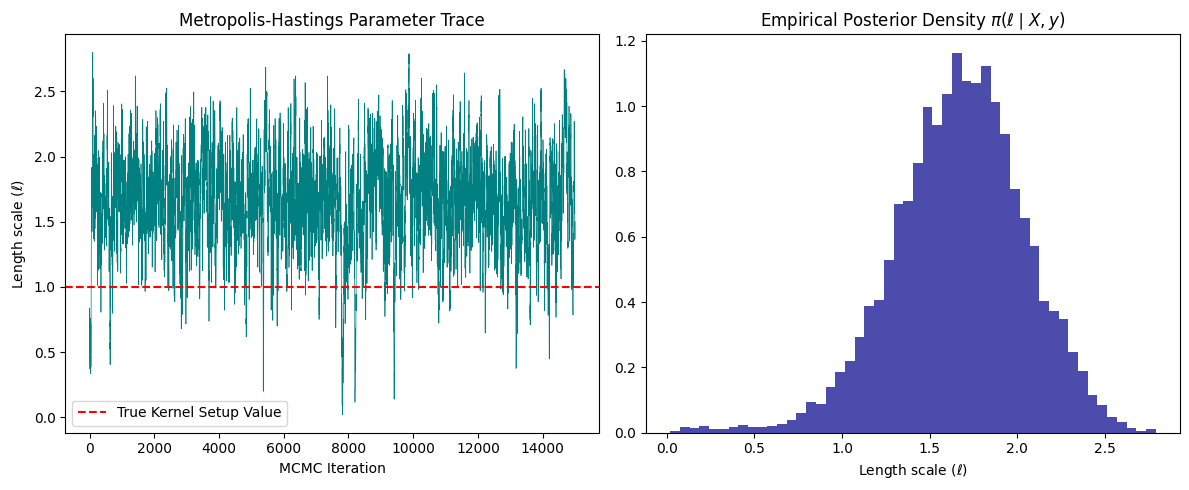

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def log_prior_lengthscale(l):
    r"""
    Evaluates the log-prior probability density.
    We assume l follows a Gamma distribution: l ~ Gamma(shape=2.0, scale=1.0)
    Density: p(l) \propto l^(shape-1) * exp(-l/scale) for l > 0
    """
    # TODO: Enforce the support boundary condition for the length scale parameter
    # Return -np.inf for non-positive values. Otherwise, return the log-density.
    if l <= 0:
        return -np.inf

    shape = 2.0
    scale = 1.0

    return (shape - 1.0) * np.log(l) - (l / scale)
    # از نظر ریاضی، ال اسکیل نمی‌تواند صفر یا منفی باشد. بنابراین در فضای لگاریتمی، احتمال مقادیر غیرمثبت را منفی بی‌نهایت فرض می‌کنیم.
    # در غیر این صورت، فرمول لگاریتم چگالی توزیع پیشین گاما را محاسبه و بازمی‌گردانیم.

def log_posterior_lengthscale(l, x_train, y_train, sigma=1.0, noise_std=0.2):
    """
    Computes the unnormalized log posterior: log pi(l) = log p(y | X, l) + log p(l)
    """
    # 1. Evaluate the prior first
    log_prior = log_prior_lengthscale(l)
    if np.isinf(log_prior):
        return -np.inf

    # TODO: Construct the noisy covariance matrix K_ell using rbf_kernel
    K = rbf_kernel(x_train, x_train, sigma=sigma, length_scale=l) + (noise_std**2) * np.eye(len(x_train))
    # ساخت ماتریس کوواریانس جدید
    # اثر نویز اندازه‌گیری با جمع کردن واریانس نویز روی قطر ماتریس اعمال می‌شود.


    try:
        # TODO: Compute the log-determinant safely using np.linalg.slogdet
        # and the matrix inverse using np.linalg.inv
        sign, logdet = np.linalg.slogdet(K)
        K_inv = np.linalg.inv(K)

        n = len(y_train)

        # TODO: Calculate the full log marginal likelihood component
        log_likelihood = -0.5 * (y_train.T @ K_inv @ y_train) - 0.5 * logdet - 0.5 * n * np.log(2 * np.pi)
        # محاسبه لگاریتم لایکلیهود حاشیه‌ای شامل سه ترم: برازش داده، جریمه پیچیدگی و ثابت نرمال‌سازی.
        # استفاده از np.linalg.slogdet برای جلوگیری از سرریزهای عددی هنگام محاسبه دترمینان است.

        # TODO: Return the unnormalized log posterior
        return log_likelihood + log_prior
        # طبق قضیه بیز در فضای لگاریتمی، لگاریتم توزیع پسین غیراستاندارد از جمع لایکلیهود و توزیع پیشین به دست می‌آید.
        # نیازی به محاسبه مخرج کسر بیز نداریم چون در نسبت الگوریتم MH خط می‌خورد.

    except np.linalg.LinAlgError:
        # Handle non-positive definite matrix instances gracefully
        return -np.inf

def metropolis_hastings(n_samples, initial_l, proposal_width=0.15):
    """
    Runs a Metropolis-Hastings sampler to generate draws from the lengthscale posterior.
    """
    samples = []
    current = initial_l
    current_logp = log_posterior_lengthscale(current, x_train, y_train)

    for i in range(n_samples):
        # TODO: Generate a candidate state using a symmetric Gaussian proposal
        proposal = np.random.normal(current, proposal_width)
        # این کار رفتار زنجیره مارکوف را در اطراف موقعیت فعلی شبیه‌سازی می‌کند.

        # TODO: Evaluate the log posterior of the proposed state
        proposal_logp = log_posterior_lengthscale(proposal, x_train, y_train)
        # سنجش اعتبار و چگالی احتمال موقعیت جدید پیشنهادی

        # TODO: Calculate the Metropolis-Hastings acceptance probability in log-space
        log_alpha = proposal_logp - current_logp
        # محاسبه نسبت پذیرش در فضای لگاریتمی که از تفاضل لگاریتم پسین جدید و قدیم به دست می‌آید.

        # TODO: Perform the Metropolis acceptance step
        # Target update variables: `current` and `current_logp`
        log_u = np.log(np.random.uniform(0, 1))
        if log_u < log_alpha:
            current = proposal
            current_logp = proposal_logp
        # یک عدد تصادفی یکنواخت در فضای لگاریتمی تولید می‌شود.
        # اگر شانس پذیرش کافی بود، زنجیره به موقعیت جدید می‌رود؛ در غیر این صورت در جای خود می‌ماند.

        samples.append(current)

    return np.array(samples)

# Execution block (Assuming x_train and y_train are derived from Part 2)
chain = metropolis_hastings(n_samples=15000, initial_l=0.5, proposal_width=0.15)

# Diagnostic Visualizations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(chain, color='teal', lw=0.5)
plt.axhline(1.0, color='red', linestyle='--', label='True Kernel Setup Value')
plt.title("Metropolis-Hastings Parameter Trace")
plt.xlabel("MCMC Iteration")
plt.ylabel(r"Length scale ($\ell$)")
plt.legend()

plt.subplot(1, 2, 2)
# Apply a 20% burn-in filter to eliminate initialization bias
burn_in = int(0.2 * len(chain))
plt.hist(chain[burn_in:], bins=50, density=True, color='darkblue', alpha=0.7)
plt.title(r"Empirical Posterior Density $\pi(\ell \mid X, y)$")
plt.xlabel(r"Length scale ($\ell$)")
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: justify; line-height: 1.8; font-family: tahoma, arial;">

## تحلیل تسک ۳ (Bayesian MCMC Inference)

نمودارها، فرآیند استخراج توزیع پسین هایپرپارامتر طول مقیاس ($l$) را به کمک زنجیره مارکوف نشان می‌دهند:

### ۱. تحلیل نمودار مسیر پارامتر (Metropolis-Hastings Parameter Trace)
* **پدیده کاترپیلار پشمالو (Fuzzy Caterpillar):** نمودار سمت چپ شبیه یک نوار متراکم و نوسانی دیده می‌شود. در MCMC، این ظاهر متراکم  نشان‌دهنده‌ی مکانیزم پذیرا و پویای الگوریتم است؛ یعنی زنجیره نه آن‌قدر قفل شده که در یک نقطه درجا بزند (عرض گام خیلی بزرگ) و نه آن‌قدر گام‌های ریزی برداشته که نتواند فضا را جستجو کند (عرض گام خیلی کوچک). این نشان می‌دهد پارامتر `proposal_width` به درستی تنظیم شده است.
* **تفاوت با مقدار واقعی تولیدکننده داده (True Setup Value):** خط چین قرمز رنگ، مقدار واقعی استفاده شده در هسته اولیه سیستم ($l = 1.0$) را نشان می‌دهد. اما زنجیره مارکوف بیشتر زمان خود را در محدوده‌ای بالاتر (بین $1.3$ تا $2.2$) سپری می‌کند و حول میانگین تقریبی $1.7$ نوسان دارد.
* **علت:** این یک پدیده طبیعی در استنتاج بیزی با داده‌های محدود است. زنجیره بر اساس داده‌های آموزش موجود قضاوت می‌کند. در این مجموعه داده، چیدمان نقاط به گونه‌ای است که Data Fit Term همراه با Complexity Penalty ترجیح می‌دهند توابع هموارتر با طول مقیاس بزرگتر را انتخاب کنند تا از Overfitting روی نویزها جلوگیری شود.

### ۲. تحلیل توزیع پسین تجربی (Empirical Posterior Density)
* نمودار هیستوگرام سمت راست، تقریب تجربی ما از توزیع ایده‌آل $\pi(l | X, y)$ است. این توزیع حالتی شبیه به توزیع نرمال با یک چولگی ملایم به سمت راست دارد. قله‌ یا مد این نمودار در محدوده $1.7$ قرار گرفته که محتمل‌ترین مقدار برای این هایپرپارامتر را با توجه به مشاهدات نشان می‌دهد.
* رگرسیون فرآیند گاوسی استاندارد معمولا با روش تک‌نقطه‌ای (مانند روش MLE) تنها یک عدد ثابت برای $l$ گزارش می‌دهد. اما نگاه بیزی مجهز به MCMC به ما یک توزیع کامل ارائه می‌دهد؛ این یعنی ما اکنون نه‌تنها می‌دانیم محتمل‌ترین طول مقیاس چقدر است، بلکه میزان عدم قطعیت و پراکندگی آن را نیز در اختیار داریم.

### نتیجه‌گیری
این تسک نشان می‌دهد زنجیره مارکوف به خوبی همگرا شده و توزیعی معقول فراتر از حدس‌های اولیه به ما ارائه داده است.

</div>

## Langevin Dynamics

Instead of updating discrete Markov chains based on algebraic acceptance criteria, we can formalize our sampling trajectories as a continuous-time path governed by a Stochastic Differential Equation (SDE). Consider the continuous-time Itô diffusion:
$$dX_t = \frac{1}{2} \nabla \log \pi(X_t) dt + dW_t$$
, where:
- $W_t$ represents a standard multi-dimensional Brownian motion process.
- $\nabla \log \pi(X_t)$ is the score function of our target distribution.

By the Fokker-Planck equation, the **stationary distribution** of this process is exactly $\pi(x)$. To simulate this continuous-time process on a computer, we use the Euler-Maruyama discretization:
$$X_{k+1} = X_k + \frac{\epsilon}{2} \nabla \log \pi(X_k) + \sqrt{\epsilon} Z_k$$
, where $\epsilon > 0$ defines the finite simulation time step size, and $Z_k \sim \mathcal{N}(0, I)$ provides the independent stochastic noise vector driving the random-walk diffusion.

Task 4: Implement the Euler-Maruyama update step to sample from a bi-modal Gaussian mixture using Unadjusted Langevin Algorithm (ULA).

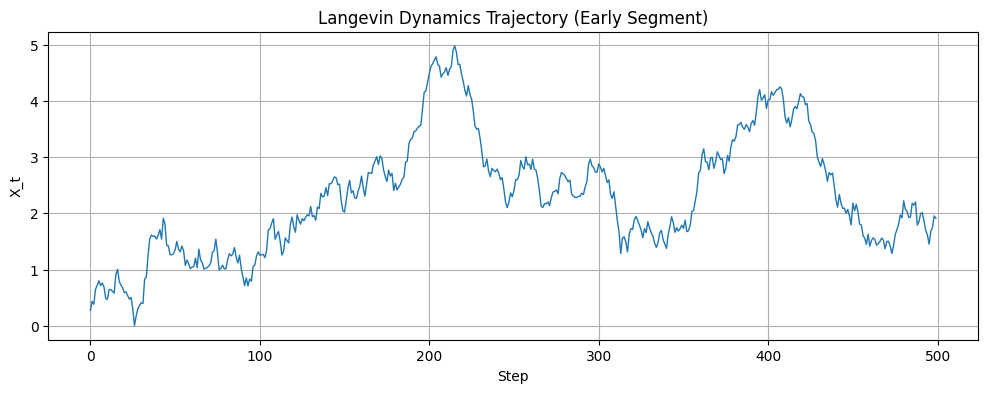

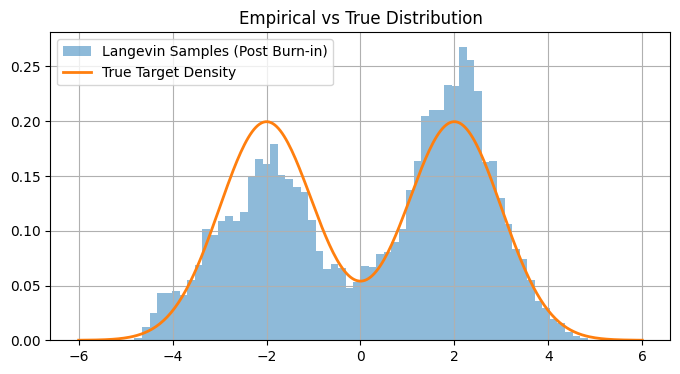

In [8]:
# Target Distribution: A mixture of two Gaussians
def log_pi(x):
    # Unnormalized log density
    return np.log(0.5*np.exp(-0.5*(x+2)**2) + 0.5*np.exp(-0.5*(x-2)**2))

def score(x):
    # Numerical approximation of the derivative of the log density
    eps = 1e-5
    return (log_pi(x + eps) - log_pi(x - eps)) / (2 * eps)

def langevin_dynamics(n_steps=20000, eps=0.02, x0=0.0):
    x = x0
    samples = []

    for _ in range(n_steps):
        # TODO: Compute the drift term
        drift = 0.5 * eps * score(x)
        # این ترم مانند گرادیان افزایشی عمل کرده و ذره را به سمت پتانسیل بالا و چگالی بالا هدایت می‌کند.

        # TODO: Compute the stochastic diffusion (noise) term
        noise = np.sqrt(eps) * np.random.randn()
        # اضافه کردن این نویز مانع از سقوط ذره شده و امکان کاوش کل فضا را فراهم می‌کند.

        # TODO: Execute the Euler-Maruyama update step
        x = x + drift + noise
        # این خط ترکیبی از حرکت هدفمند به سمت قله‌ها و سرگردانی تصادفی (جستجو) است.

        samples.append(x)

    return np.array(samples)

samples = langevin_dynamics(n_steps=20000, eps=0.02, x0=0.0)

# Plot Trajectory
plt.figure(figsize=(12,4))
plt.plot(samples[:500], lw=1)
plt.title("Langevin Dynamics Trajectory (Early Segment)")
plt.xlabel("Step")
plt.ylabel("X_t")
plt.grid(True)
plt.show()

# Verify Stationary Distribution
grid = np.linspace(-6,6,300)
true_density = np.exp([log_pi(x) for x in grid])
true_density /= np.trapezoid(true_density, grid) # Normalize

plt.figure(figsize=(8,4))
plt.hist(samples[5000:], bins=60, density=True, alpha=0.5, label="Langevin Samples (Post Burn-in)")
plt.plot(grid, true_density, lw=2, label="True Target Density")
plt.title("Empirical vs True Distribution")
plt.legend()
plt.grid(True)
plt.show()

<div dir="rtl" style="text-align: justify; line-height: 1.8; font-family: tahoma, arial;">

## تحلیل تسک ۴ (Langevin Dynamics & ULA)

با نگاه به دو نمودار، رفتارهای زیر قابل تحلیل است:

### ۱. تحلیل نمودار مسیر حرکت (Langevin Dynamics Trajectory)
* **ماندگاری در مود مثبت در گام‌های اولیه:** در نمودار مسیر حرکت ۵۰۰ گام اول، مقدار $x_t$ کاملا در ناحیه مثبت (بین ۰ تا ۵) قرار دارد. ذره کار خود را از نزدیکی صفر شروع کرده، حوالی گام ۲۰۰ تا قله‌ی پتانسیل ۵ بالا رفته و سپس دوباره به محدوده مود مثبت (حوالی ۲) بازگشته است.
* **شهود پدیده قفل‌شدگی موقت (Local Entrapment):** این رفتار یک چالش کلاسیک در نمونه‌برداری از توزیع‌های چندوجهی (Multi-modal) است. ذره در ابتدا درون پتانسیل جذاب مود مثبت گیر افتاده است. اما همبستگی این نمودار با هیستوگرام نهایی (که هر دو مود منفی و مثبت را کامل پوشش داده) ثابت می‌کند که الگوریتم ULA در گام‌های بالاتر به کمک ترم نفوذ تصادفی ($\sqrt{\epsilon}Z_k$) بالاخره توانسته از این سد عبور کند و مود منفی را هم با موفقیت کشف کند.

### ۲. انطباق توزیع تجربی و واقعی (Empirical vs True Distribution)
* **تایید قضیه فوکر-پلانک:** ستون‌های آبی‌رنگ (نمونه‌های Post Burn-in) با دقت خوبی بر منحنی نارنجی‌رنگ (توزیع هدف واقعی) منطبق شده‌اند. طبق معادله فوکر-پلانک، توزیع ایستای این فرآیند نفوذ پیوسته، دقیقا همان توزیع هدف $\pi(x)$ خواهد بود و این نمودار صحت این ادعای ریاضی را در عمل اثبات می‌کند.
* **بازسازی دقیق قله‌ها و دره:** الگوریتم نه تنها دو قله‌ی اصلی در $x = 2$ و $x = -2$ را با فرکانس صحیح بازسازی کرده، بلکه با کاهش چگالی نمونه‌ها در نقطه عطف $x = 0$ (دره میان دو مود)، نشان داده که فضای کم‌پتانسیل را هم به درستی تشخیص داده است.

### ۳. اهمیت Burn-in Period
حذف بخش اولیه مسیر (Early Segment) برای ترسیم هیستوگرام یک ضرورت بود. ذره کار خود را از یک نقطه اولیه دلخواه (نزدیک به صفر) آغاز می‌کند و مدتی زمان می‌برد تا به تعادل آماری (Equilibrium) و توزیع ایستای خود برسد. نمونه‌های خارج شده پس از این فاز، کاملا مستقل از نقطه شروع اولیه بوده و بازتاب‌دهنده‌ی چگالی واقعی سیستم هستند.

### نتیجه‌گیری
 در نهایت با تلفیق فیزیک و آمار در دینامیک لانژون، از اطلاعات گرادیان برای نمونه‌برداری از توابع چندوجهی و پیچیده استفاده کردیم.

</div>